# Notebook - Predicción de ocurrencia de accidentes # 
---

# Resumen ejecutivo

En este notebook se documentan las pruebas realizadas para predecir la ocurrencia de accidentes:

1. Se trabaja sobre el dataset original, encontrando que el metodo que se utilizó para balancear los datos hace que las predicciones de los modelos regresión logistica, random forest y XGBoost tengan un desempeño no confiable para este conjunto de datos con un AUC cercano al 0.5 para todos los modelos.
2. Se procede a agrupar los datos en clusters geográficos por coordenadas utilizado K medias y se balancean los datos asignando OCURRENCIA_ACCIDENTE=0 a todas las franjas horarias de todos los días y meses en los cuales no hay registros de accidentes para cada uno de los clusters.
3. Se observa que el desempeño de los modelos en general mejora con esta nueva forma de balancear los datos (aún no se incluyen las variables meteorológicas).
4. Se procede a complementar la información meteorológica de los datos con OCURRENCIA_ACCIDENTE=0
5. Al entrenar los modelos luego de hacer las modificaciones de los puntos 3 y 4, se observa que el desempeño de los modelos mejora en general y que el modelo con el mejor AUC-ROC es XGBoost Classifier con 0.82.

In [1]:
# Actualizar scikit learn a última versión
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
#Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# 1. Dataset original
---

El dataset inicial está conformado principalmente por los registros de accidentes en Bogotá tomados de la Secretería de movilidad y cuenta con información geográfica y fecha. Los datos de la secretaría de movilidad fueron complementados con información meteorológica histórica de OpenMeteo, y adicionalmente se generaron datos con OCURRIO_ACCIDENTE=0 para balancear el conjunto. El método usado para generar los '0's consistió en tomar cada accidente en la celda (CELDA_ID) con la hora y se desplazo la fecha de 1 a 8 días, validando que no existiera accidente en ese mismo lugar y hora.

## 1.1 Análisis exploratorio

In [3]:
# Carga de datos, Modificar ruta segun se requiera
df_original = pd.read_csv('/kaggle/input/datasets/caalsial/dataset-ocurrencia/DATASET_OCURRENCIA.csv')
#Cantidad de observaciones y variables del dataset
df_original.shape

(993516, 22)

In [4]:
#Tipo de datos del dataset
df_original.dtypes

PAR_ID                    int64
CELDA_ID                 object
FECHA_HORA               object
LATITUD                 float64
LONGITUD                float64
CELDA_X                   int64
CELDA_Y                   int64
ANIO                      int64
MES                       int64
DIA_SEMANA                int64
HORA                      int64
FIN_SEMANA                int64
TEMPERATURA_2M          float64
HUMEDAD_RELATIVA_2M     float64
SENSACION_TERMICA       float64
PRECIPITACION           float64
LLUVIA                  float64
NUBOSIDAD               float64
PRESION_SUPERFICIE      float64
VELOCIDAD_VIENTO_10M    float64
DIRECCION_VIENTO_10M    float64
OCURRIO_ACCIDENTE         int64
dtype: object

In [5]:
df_original.head(5)

,PAR_ID,CELDA_ID,FECHA_HORA,LATITUD,LONGITUD,CELDA_X,CELDA_Y,ANIO,MES,DIA_SEMANA,...,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M,OCURRIO_ACCIDENTE
0,135390,1975_2005,2007-01-01 00:00:00,4.621060,-74.187908,1975,2005,2007,1,0,...,13.5,85.0,13.0,0.0,0.0,88.0,755.1,5.9,101.0,0
1,113893,1976_2007,2007-01-01 00:00:00,4.630104,-74.183403,1976,2007,2007,1,0,...,13.1,89.0,12.8,0.0,0.0,91.0,756.6,5.1,94.0,1
2,323638,1994_2032,2007-01-01 00:00:00,4.743150,-74.102296,1994,2032,2007,1,0,...,11.6,88.0,10.7,0.0,0.0,97.0,739.5,5.7,108.0,1
3,126027,1999_2007,2007-01-01 00:00:00,4.630112,-74.079761,1999,2007,2007,1,0,...,11.6,88.0,10.7,0.0,0.0,97.0,739.5,5.7,108.0,1
4,7373,2001_2029,2007-01-01 00:00:00,4.729586,-74.070748,2001,2029,2007,1,0,...,11.6,88.0,10.7,0.0,0.0,97.0,739.5,5.7,108.0,0


In [6]:
#Estadísticas descriptivas de las variables numéricas
df_original.describe()

,PAR_ID,LATITUD,LONGITUD,CELDA_X,CELDA_Y,ANIO,MES,DIA_SEMANA,HORA,FIN_SEMANA,TEMPERATURA_2M,HUMEDAD_RELATIVA_2M,SENSACION_TERMICA,PRECIPITACION,LLUVIA,NUBOSIDAD,PRESION_SUPERFICIE,VELOCIDAD_VIENTO_10M,DIRECCION_VIENTO_10M,OCURRIO_ACCIDENTE
count,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.000000,993516.0
mean,248384.882480,4.649475,-74.102363,1993.984051,2011.282641,2015.439594,6.557981,2.923172,12.897163,0.258220,14.694015,73.595399,13.817877,0.164922,0.163319,83.983677,748.776036,6.944233,149.586159,0.5
std,143404.297696,0.056155,0.039804,8.833160,12.419239,5.154019,3.388994,1.915450,5.469226,0.437656,3.389075,17.869909,3.610258,0.516228,0.512419,21.861273,12.974394,4.573917,66.062372,0.5
min,0.000000,4.471856,-74.219452,1968.000000,1972.000000,2007.000000,1.000000,0.000000,0.000000,0.000000,-0.500000,6.000000,-3.700000,0.000000,0.000000,0.000000,686.800000,0.000000,2.000000,0.0
25%,124195.000000,4.607504,-74.129335,1988.000000,2002.000000,2011.000000,4.000000,1.000000,9.000000,0.000000,12.100000,60.000000,11.300000,0.000000,0.000000,76.000000,740.700000,3.600000,114.000000,0.0
50%,248385.500000,4.643677,-74.102290,1994.000000,2010.000000,2016.000000,7.000000,3.000000,13.000000,0.000000,14.600000,75.000000,13.900000,0.000000,0.000000,95.000000,754.500000,5.800000,127.000000,0.5
75%,372576.000000,4.688892,-74.070749,2001.000000,2020.000000,2019.000000,10.000000,5.000000,17.000000,1.000000,17.400000,90.000000,16.500000,0.100000,0.100000,99.000000,757.800000,9.200000,153.000000,1.0
max,496966.000000,4.824537,-74.012159,2014.000000,2050.000000,2026.000000,12.000000,6.000000,23.000000,1.000000,26.100000,100.000000,26.800000,13.600000,13.600000,100.000000,766.700000,32.700000,360.000000,1.0


In [7]:
#Porcentaje de observaciones por ocurrencia de accidente
df_original['OCURRIO_ACCIDENTE'].value_counts(normalize=True)

OCURRIO_ACCIDENTE
0    0.5
1    0.5
Name: proportion, dtype: float64

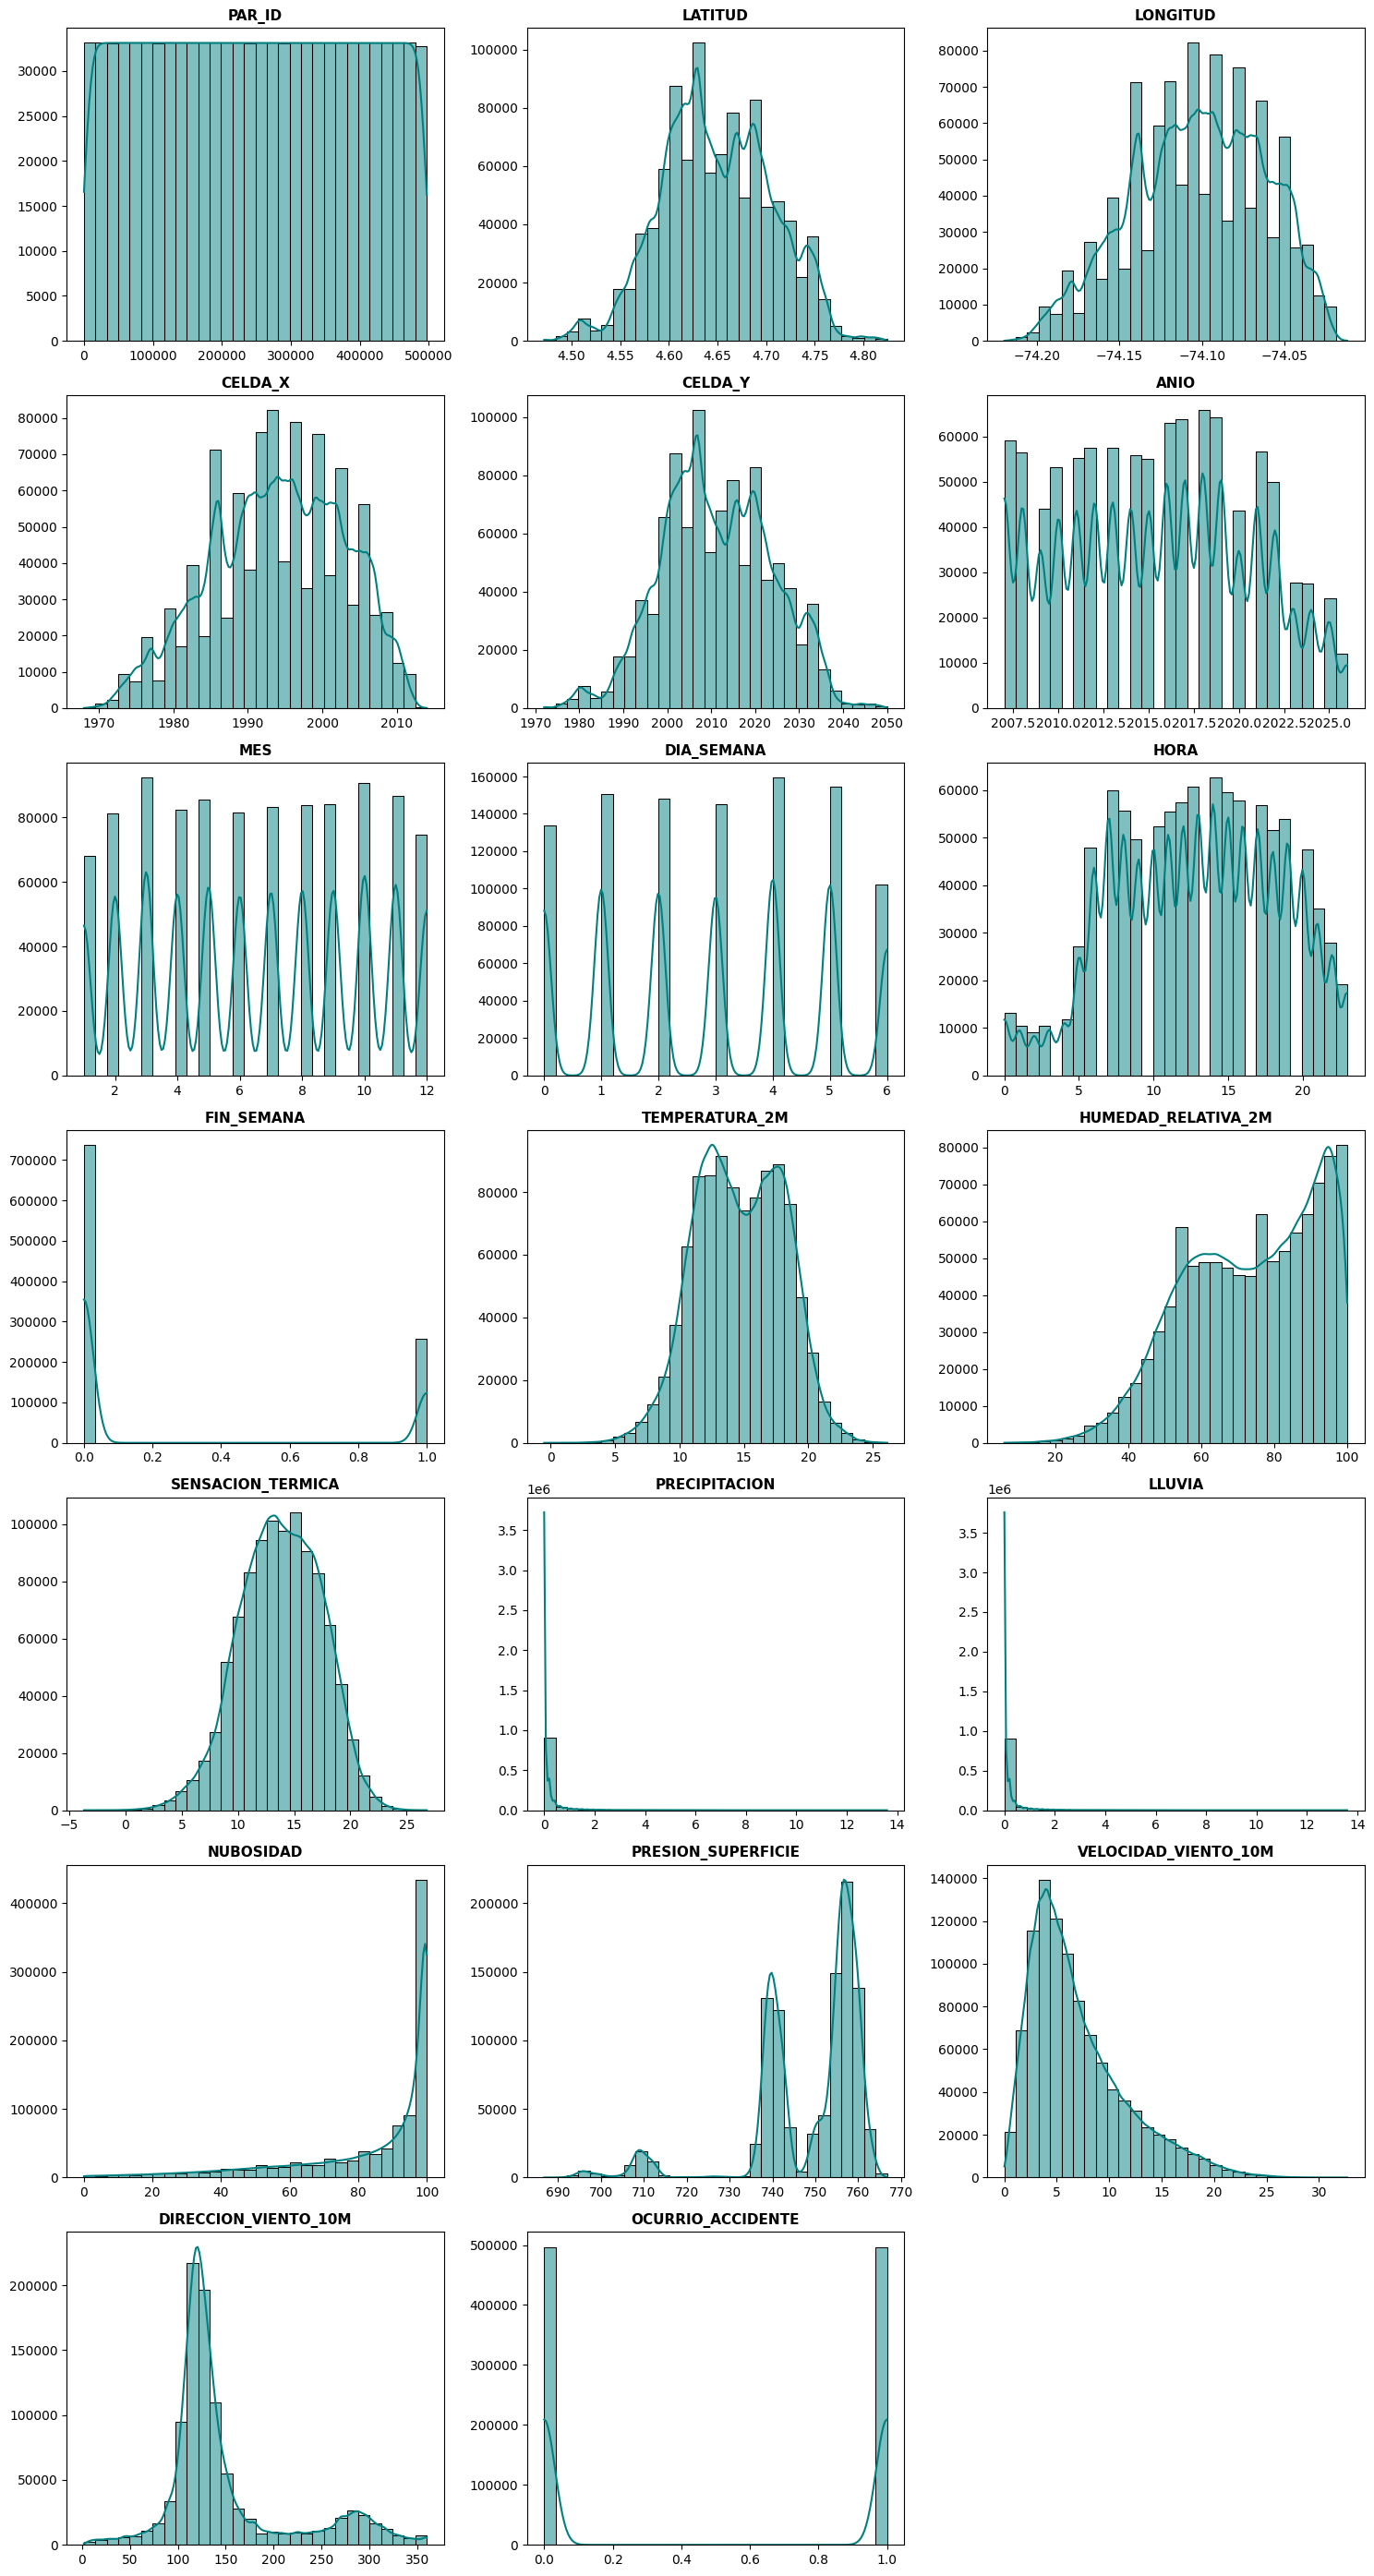

In [8]:
#Visualización de distribuciones de variables numéricas
numeric_cols = df_original.select_dtypes(include=['number']).columns.tolist() # Seleccionar columnas numéricas

# Configurar el tamaño de la figura según la cantidad de variables numéricas
num_cols = len(numeric_cols) # de variables numéricas
cols_per_row = 3
rows = (num_cols + cols_per_row - 1) // cols_per_row # Calcular número de filas necesarias

# Crear subplots para cada variable numérica
plt.figure(figsize=(cols_per_row * 5, rows * 4)) # Ajustar tamaño de la figura
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(df_original[col], bins=30, kde=True, color='teal', edgecolor='black')
    plt.title(col, fontsize=11, weight='bold')
    plt.xlabel("")
    plt.ylabel("")
plt.tight_layout() # Ajustar el diseño para evitar solapamientos
plt.show()

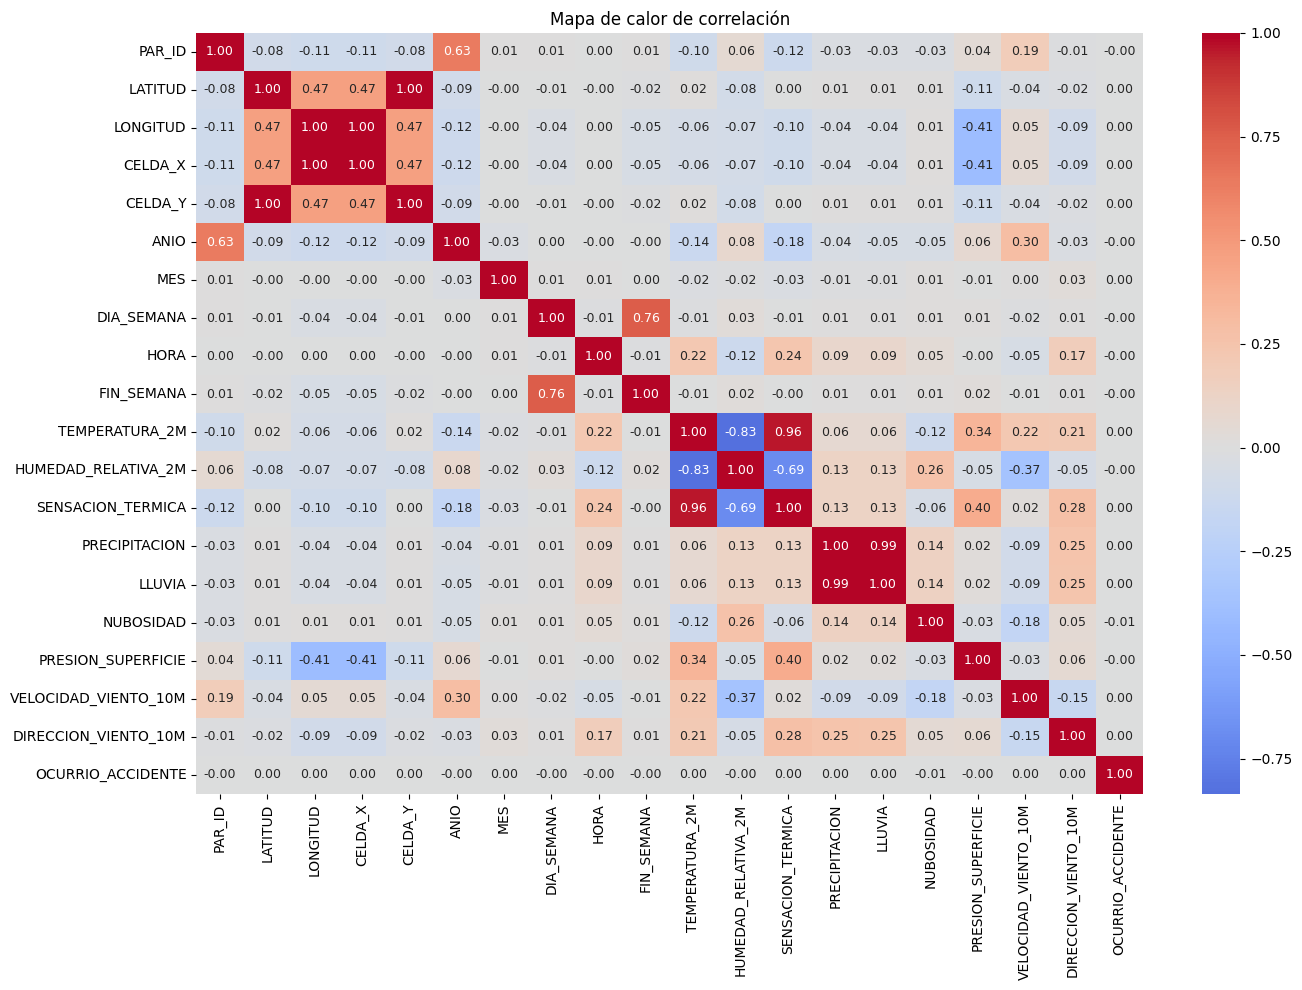

In [9]:
#Matriz de correlación
corr=df_original.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={'size': 9})
plt.title("Mapa de calor de correlación")
plt.tight_layout()
plt.show()

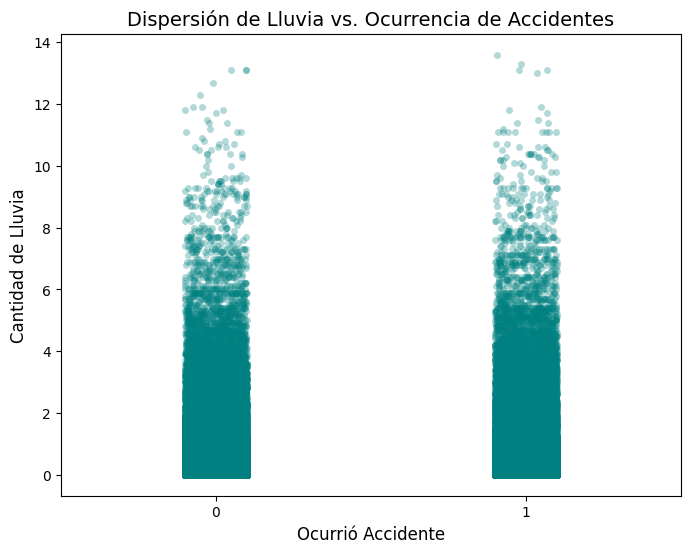

In [10]:
plt.figure(figsize=(8, 6))
sns.stripplot(x='OCURRIO_ACCIDENTE', y='LLUVIA', data=df_original, 
              jitter=True, alpha=0.3, color='teal')

plt.title('Dispersión de Lluvia vs. Ocurrencia de Accidentes', fontsize=14)
plt.xlabel('Ocurrió Accidente', fontsize=12)
plt.ylabel('Cantidad de Lluvia', fontsize=12)

plt.show()

## 1.2 Entrenamiento y pruebas sin variables meteorológicas

### 1.2.1 Separación de conjunto de datos

In [11]:
df_original.columns

Index(['PAR_ID', 'CELDA_ID', 'FECHA_HORA', 'LATITUD', 'LONGITUD', 'CELDA_X',
       'CELDA_Y', 'ANIO', 'MES', 'DIA_SEMANA', 'HORA', 'FIN_SEMANA',
       'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M', 'SENSACION_TERMICA',
       'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD', 'PRESION_SUPERFICIE',
       'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M', 'OCURRIO_ACCIDENTE'],
      dtype='object')

In [12]:
"""Se seleccionan las columnas requeridas para el entrenamiento de modelos sin las variables del clima. 
Se eliminan las variables que inicialmente no aportan al problema: PAR_ID,CELDA_ID, FECHA_HORA, LATITUD, LONGITUD, ANIO, FIN """

columnas_predictoras = ['CELDA_X', 'CELDA_Y','MES', 'DIA_SEMANA', 'HORA']

In [13]:
#Se separan los datos en entrenamiento y prueba, se fija la variable OCURRIO_ACCIDENTE como variable a predecir.

from sklearn.model_selection import train_test_split

# Se separan las variables
X = df_original[columnas_predictoras]
y = df_original['OCURRIO_ACCIDENTE']

#  Se dividen los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,
    random_state=42
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (794812, 5)
Tamaño de X_test: (198704, 5)


### 1.2.2 Regresión logística

In [14]:
#Librerias de sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,precision_score, recall_score, log_loss)

In [15]:
# Se crea el modelo base de regresión logística
log_reg_base= LogisticRegression(max_iter=1000, random_state=42)

In [16]:
#Se escalan los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
#Calibración de hiperparámetros
parametros_lr = {
'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0, 0.25, 0.5, 0.75], 
    'solver': ['saga']
}

#Grid search para encontrar el mejor modelo
grid_search_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=parametros_lr,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_lr.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_lr = grid_search_lr.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_lr.best_params_}\n")

Duración del entrenamiento 6 minutos y 23 segundos
Mejores parámetros encontrados: {'C': 0.001, 'l1_ratio': 0.25, 'solver': 'saga'}



In [18]:
#Predicciones
y_pred_lr = mejor_lr.predict(X_test_scaled)
y_prob_lr = mejor_lr.predict_proba(X_test_scaled)[:, 1]

#Se calculan las métricas
metricas = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_lr),
    "Log Loss": log_loss(y_test, y_prob_lr)
}

print("--- Resultados del Modelo: Regresión Logística Calibrada ---")
for metrica, valor in metricas.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados del Modelo: Regresión Logística Calibrada ---
ROC-AUC               : 0.4987
F1 Score              : 0.5983
Balanced Accuracy     : 0.4963
Precision             : 0.4960
Recall (Sensibilidad) : 0.7537
Log Loss              : 0.6932


### 1.2.3 Random Forest

In [19]:
#Librerias de sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,precision_score, recall_score, log_loss)
from sklearn.ensemble import RandomForestClassifier

In [20]:
# Se crea el modelo base de RF Classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

In [21]:
#Calibración de hiperparámetros
parametros_rf = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [5, 10],          
    'min_samples_split': [2, 5] 
}

#Grid search para encontrar el mejor modelo
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=parametros_rf,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_rf.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_rf = grid_search_rf.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_rf.best_params_}\n")

Duración del entrenamiento 22 minutos y 13 segundos
Mejores parámetros encontrados: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 150}



In [22]:
# Se encuentran las variables de mayor importancia
importancias = mejor_rf.feature_importances_

df_importancias = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

df_importancias

,Variable,Importancia
2,MES,0.846910
4,HORA,0.046757
1,CELDA_Y,0.041698
0,CELDA_X,0.033707
3,DIA_SEMANA,0.030928


In [23]:
#Predicciones
y_pred_rf = mejor_rf.predict(X_test)
y_prob_rf = mejor_rf.predict_proba(X_test)[:, 1]

#Se calculan las métricas
metricas_rf = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_rf),
    "Log Loss": log_loss(y_test, y_prob_rf)
}

print("--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---")
for metrica, valor in metricas_rf.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---
ROC-AUC               : 0.5187
F1 Score              : 0.3292
Balanced Accuracy     : 0.5142
Precision             : 0.5301
Recall (Sensibilidad) : 0.2387
Log Loss              : 0.6924


### 1.2.4 XGBoost

In [24]:
!pip install --upgrade xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 7.0 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.2.0
    Uninstalling xgboost-3.2.0:
      Successfully uninstalled xgboost-3.2.0


In [25]:
# Librerías
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,precision_score, recall_score, log_loss)
from xgboost import XGBClassifier

In [26]:
#Modelo baso de XGB Classifier
xgb_base = XGBClassifier(random_state=42, n_jobs=-1, device='cuda')

In [27]:
# Calibración de hiperparámetros
parametros_xgb = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2] 
}

#Grid search para encontrar el mejor modelo
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_xgb,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_xgb.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_xgb = grid_search_xgb.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_xgb.best_params_}\n")

Duración del entrenamiento 1 minutos y 21 segundos
Mejores parámetros encontrados: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 50}



In [28]:
#Predicciones
y_pred_xgb = mejor_xgb.predict(X_test)
y_prob_xgb = mejor_xgb.predict_proba(X_test)[:, 1]

#Metricas
metricas_xgb = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_xgb),
    "Log Loss": log_loss(y_test, y_prob_xgb)
}

print("--- Resultados de XGBoost ---")
for metrica, valor in metricas_xgb.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de XGBoost ---
ROC-AUC               : 0.5236
F1 Score              : 0.4987
Balanced Accuracy     : 0.5168
Precision             : 0.5165
Recall (Sensibilidad) : 0.4820
Log Loss              : 0.6925


### 1.2.5 MLP Classifier

In [29]:
#Librerias
from sklearn.neural_network import MLPClassifier

In [30]:
# Modelo base
mlp = MLPClassifier(max_iter=100, random_state=42, early_stopping=True,n_iter_no_change=5,)

In [31]:
#Calibracion de hiperparametros
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

#Grid search para encontrar el mejor modelo
grid_search_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_mlp.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_mlp = grid_search_mlp.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_mlp.best_params_}\n")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Duración del entrenamiento 13 minutos y 41 segundos
Mejores parámetros encontrados: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}



In [32]:
#Predicciones
y_pred_mlp = mejor_mlp.predict(X_test_scaled)
y_prob_mlp = mejor_mlp.predict_proba(X_test_scaled)[:, 1]

#Metricas
metricas_mlp = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp),
    "F1 Score": f1_score(y_test, y_pred_mlp),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_mlp),
    "Log Loss": log_loss(y_test, y_prob_mlp)
}

print("--- Resultados de MLP ---")
for metrica, valor in metricas_mlp.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de MLP ---
ROC-AUC               : 0.5191
F1 Score              : 0.3127
Balanced Accuracy     : 0.5132
Precision             : 0.5302
Recall (Sensibilidad) : 0.2218
Log Loss              : 0.6925


### 1.2.6 Comparación de modelos

In [33]:
df_comparacion = pd.DataFrame({
    'Regresión Logística': metricas,
    'Random Forest': metricas_rf,
    'XGBoost': metricas_xgb,
    'MLP': metricas_mlp,
})


print("--- Comparación de Modelos para el dataset original sin clima ---")
display(df_comparacion.round(4))

--- Comparación de Modelos para el dataset original sin clima ---


,Regresión Logística,Random Forest,XGBoost,MLP
ROC-AUC,0.4987,0.5187,0.5236,0.5191
F1 Score,0.5983,0.3292,0.4987,0.3127
Balanced Accuracy,0.4963,0.5142,0.5168,0.5132
Precision,0.4960,0.5301,0.5165,0.5302
Recall (Sensibilidad),0.7537,0.2387,0.4820,0.2218
Log Loss,0.6932,0.6924,0.6925,0.6925


## 1.3 Entrenamiento y pruebas con variables meteorológicas

### 1.3.1 Separación de conjunto de datos

In [34]:
"""Se seleccionan las columnas requeridas para el entrenamiento de modelos incluyendo las variables del clima que se considera pueden afectar la accidentalidad, respecto a
variables correlacionadas se usa unicamente la sensación térmica en vez de la temperatura y la lluvia en lugar de la precipitación.
Se eliminan las variables que inicialmente no aportan al problema: PAR_ID,CELDA_ID, FECHA_HORA, LATITUD, LONGITUD, ANIO, FIN """

columnas_predictoras = ['CELDA_X', 'CELDA_Y','MES', 'DIA_SEMANA', 'HORA','SENSACION_TERMICA','LLUVIA','VELOCIDAD_VIENTO_10M']

In [35]:
#Se separan los datos en entrenamiento y prueba, se fija la variable OCURRIO_ACCIDENTE como variable a predecir.

from sklearn.model_selection import train_test_split

# Se separan las variables
X = df_original[columnas_predictoras]
y = df_original['OCURRIO_ACCIDENTE']

#  Se dividen los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,
    random_state=42
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (794812, 8)
Tamaño de X_test: (198704, 8)


### 1.3.1 Regresión logística

In [36]:
# Se crea el modelo base de regresión logística
log_reg_base= LogisticRegression(max_iter=1000, random_state=42)

In [37]:
#Se escalan los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
#Calibración de hiperparámetros
parametros_lr = {
'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0, 0.25, 0.5, 0.75], 
    'solver': ['saga']
}

#Grid search para encontrar el mejor modelo
grid_search_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=parametros_lr,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_lr.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_lr = grid_search_lr.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_lr.best_params_}\n")

Duración del entrenamiento 4 minutos y 51 segundos
Mejores parámetros encontrados: {'C': 0.001, 'l1_ratio': 0.25, 'solver': 'saga'}



In [39]:
#Predicciones
y_pred_lr = mejor_lr.predict(X_test_scaled)
y_prob_lr = mejor_lr.predict_proba(X_test_scaled)[:, 1]

#Se calculan las métricas
metricas = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_lr),
    "Log Loss": log_loss(y_test, y_prob_lr)
}

print("--- Resultados del Modelo: Regresión Logística Calibrada ---")
for metrica, valor in metricas.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados del Modelo: Regresión Logística Calibrada ---
ROC-AUC               : 0.4996
F1 Score              : 0.5922
Balanced Accuracy     : 0.4981
Precision             : 0.4972
Recall (Sensibilidad) : 0.7321
Log Loss              : 0.6931


### 1.3.2 Random Forest

In [40]:
# Se crea el modelo base de RF Classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

In [41]:
#Calibración de hiperparámetros
parametros_rf = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [5, 10],          
    'min_samples_split': [2, 5] 
}

#Grid search para encontrar el mejor modelo
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=parametros_rf,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_rf.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_rf = grid_search_rf.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_rf.best_params_}\n")

Duración del entrenamiento 23 minutos y 9 segundos
Mejores parámetros encontrados: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}



In [42]:
# Se encuentran las variables de mayor importancia
importancias = mejor_rf.feature_importances_

df_importancias = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

df_importancias

,Variable,Importancia
2,MES,0.733335
5,SENSACION_TERMICA,0.058608
7,VELOCIDAD_VIENTO_10M,0.057965
4,HORA,0.038830
6,LLUVIA,0.033956
1,CELDA_Y,0.032376
0,CELDA_X,0.029528
3,DIA_SEMANA,0.015401


In [43]:
#Predicciones
y_pred_rf = mejor_rf.predict(X_test)
y_prob_rf = mejor_rf.predict_proba(X_test)[:, 1]

#Se calculan las métricas
metricas_rf = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_rf),
    "Log Loss": log_loss(y_test, y_prob_rf)
}

print("--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---")
for metrica, valor in metricas_rf.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---
ROC-AUC               : 0.5190
F1 Score              : 0.3411
Balanced Accuracy     : 0.5145
Precision             : 0.5289
Recall (Sensibilidad) : 0.2517
Log Loss              : 0.6925


### 1.3.4 XGBoost

In [44]:
#Modelo baso de XGB Classifier
xgb_base = XGBClassifier(random_state=42, n_jobs=-1, device='cuda')

In [45]:
# Calibración de hiperparámetros
parametros_xgb = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2] 
}

#Grid search para encontrar el mejor modelo
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_xgb,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_xgb.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_xgb = grid_search_xgb.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_xgb.best_params_}\n")

Duración del entrenamiento 1 minutos y 33 segundos
Mejores parámetros encontrados: {'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 150}



In [46]:
#Predicciones
y_pred_xgb = mejor_xgb.predict(X_test)
y_prob_xgb = mejor_xgb.predict_proba(X_test)[:, 1]

#Metricas
metricas_xgb = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_xgb),
    "Log Loss": log_loss(y_test, y_prob_xgb)
}

print("--- Resultados de XGBoost ---")
for metrica, valor in metricas_xgb.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de XGBoost ---
ROC-AUC               : 0.5239
F1 Score              : 0.4780
Balanced Accuracy     : 0.5162
Precision             : 0.5174
Recall (Sensibilidad) : 0.4443
Log Loss              : 0.6922


### 1.3.5 MLP Classifier

In [47]:
# Modelo base
mlp = MLPClassifier(max_iter=100, random_state=42, early_stopping=True,n_iter_no_change=5)

In [48]:
#Calibracion de hiperparametros
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

#Grid search para encontrar el mejor modelo
grid_search_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_mlp.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_mlp = grid_search_mlp.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_mlp.best_params_}\n")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Duración del entrenamiento 13 minutos y 54 segundos
Mejores parámetros encontrados: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}



In [49]:
#Predicciones
y_pred_mlp = mejor_mlp.predict(X_test_scaled)
y_prob_mlp = mejor_mlp.predict_proba(X_test_scaled)[:, 1]

#Metricas
metricas_mlp = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp),
    "F1 Score": f1_score(y_test, y_pred_mlp),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_mlp),
    "Log Loss": log_loss(y_test, y_prob_mlp)
}

print("--- Resultados de MLP ---")
for metrica, valor in metricas_mlp.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de MLP ---
ROC-AUC               : 0.5161
F1 Score              : 0.4220
Balanced Accuracy     : 0.5116
Precision             : 0.5153
Recall (Sensibilidad) : 0.3574
Log Loss              : 0.6927


### 1.3.6 Comparación de modelos

In [50]:
df_comparacion = pd.DataFrame({
    'Regresión Logística': metricas,
    'Random Forest': metricas_rf,
    'XGBoost': metricas_xgb,
    'MLP': metricas_mlp,
})


print("--- Comparación de Modelos para el dataset original con clima ---")
display(df_comparacion.round(4))

--- Comparación de Modelos para el dataset original con clima ---


,Regresión Logística,Random Forest,XGBoost,MLP
ROC-AUC,0.4996,0.5190,0.5239,0.5161
F1 Score,0.5922,0.3411,0.4780,0.4220
Balanced Accuracy,0.4981,0.5145,0.5162,0.5116
Precision,0.4972,0.5289,0.5174,0.5153
Recall (Sensibilidad),0.7321,0.2517,0.4443,0.3574
Log Loss,0.6931,0.6925,0.6922,0.6927


# 2. Clusters geograficos
---

Dado el bajo rendimiento predictivo con el dataset original, se propone agrupar los datos en clusters geográficos por coordenadas utilizado K medias y se balancean los datos asignando OCURRENCIA_ACCIDENTE=0 a todas las franjas horarias de todos los días y meses en los cuales no hay registros de accidentes para cada uno de los clusters.

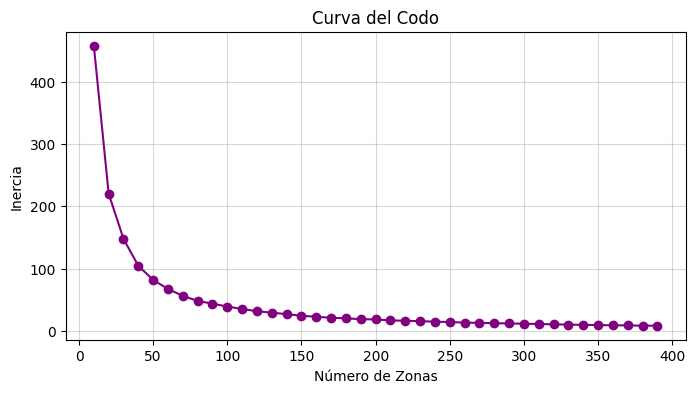

In [51]:
from sklearn.cluster import MiniBatchKMeans

#Curva del codo para k medias
coordenadas = df_original[['LATITUD', 'LONGITUD']]
inercias = []
rango_k = range(10, 400, 10)

for k in rango_k:
    kmeans_temp = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=3)
    kmeans_temp.fit(coordenadas)
    inercias.append(kmeans_temp.inertia_)

# Mostrar la curva
plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker='o', color='purple')
plt.title('Curva del Codo')
plt.xlabel('Número de Zonas')
plt.ylabel('Inercia')
plt.grid(True, alpha=0.5)
plt.show()

In [52]:
#Se propone usar n_clusters=150 dado que es posterior al codo de la gráfica y se considera una buena agrupación espacial para Bogotá
k=150

In [53]:
#K-medias con las zonas definidas según el codo
kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=3)
df_original['ZONA_CIUDAD'] = kmeans.fit_predict(coordenadas)

In [54]:
from itertools import product

# Se crea un DataFrame con los centroides de cada cluster (ZONA_CIUDAD, LATITUD_CENTROIDE, LONGITUD_CENTROIDE)
centroides_df = pd.DataFrame(
    kmeans.cluster_centers_, 
    columns=['LATITUD_CENTROIDE', 'LONGITUD_CENTROIDE']
).reset_index().rename(columns={'index': 'ZONA_CIUDAD'})


# Se guardan los datos de los accidentes que realmenet ocurrieron y se agrupan
df_reales = df_original[df_original['OCURRIO_ACCIDENTE'] == 1].copy()
agregaciones = {
    'OCURRIO_ACCIDENTE': 'max',  # Si hubo al menos un accidente, la etiqueta es 1
    'SENSACION_TERMICA': 'mean', 
    'LLUVIA': 'mean', 
    'NUBOSIDAD': 'mean', 
    'VELOCIDAD_VIENTO_10M': 'mean'
}
df_agrupado = df_reales.groupby(['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA']).agg(agregaciones).reset_index()


#Se crea una cuadricula para todas las combinacioens posibles de zona, mes, dia hora
cuadricula = pd.DataFrame(
    list(product(range(k), range(1, 13), range(0, 7), range(0, 24))), 
    columns=['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA']
)


# Se asigna OCURRIO_ACCIDENTE=0 para todas las combinaciones que no tienen accidentes
# Las columnas de clima quedan como NaN para las celdas con 0
df = pd.merge(cuadricula, df_agrupado, on=['ZONA_CIUDAD', 'MES', 'DIA_SEMANA', 'HORA'], how='left')
df['OCURRIO_ACCIDENTE'] = df['OCURRIO_ACCIDENTE'].fillna(0)

# Se agrega la latitud y longitud del centroide correspondiente a cada fila según su ZONA_CIUDAD
df = pd.merge(df, centroides_df, on='ZONA_CIUDAD', how='left')

In [55]:
# Agrupar por zona y agregar accidentes
accidentes_por_zona = df.groupby('ZONA_CIUDAD')['OCURRIO_ACCIDENTE'].sum().reset_index()
accidentes_por_zona.rename(columns={'OCURRIO_ACCIDENTE': 'TOTAL_ACCIDENTES'}, inplace=True)

total_zonas = len(accidentes_por_zona)
promedio_accidentes_zona = accidentes_por_zona['TOTAL_ACCIDENTES'].mean()
zona_mas_peligrosa = accidentes_por_zona.loc[accidentes_por_zona['TOTAL_ACCIDENTES'].idxmax()]

print(f"Cantidad total de zonas analizadas : {total_zonas}")
print(f"Promedio de accidentes por zona    : {promedio_accidentes_zona:.1f} accidentes")
print(f"Zona con más accidentes            : Zona {int(zona_mas_peligrosa['ZONA_CIUDAD'])} (con {int(zona_mas_peligrosa['TOTAL_ACCIDENTES'])} accidentes registrados)")

Cantidad total de zonas analizadas : 150
Promedio de accidentes por zona    : 1386.5 accidentes
Zona con más accidentes            : Zona 48 (con 1785 accidentes registrados)


In [56]:
import folium
# Se agrupan los accidentes
df_puntos = df_original[df_original['OCURRIO_ACCIDENTE'] == 1].copy()

# Se calculan los centroides
centroides = df_puntos.groupby('ZONA_CIUDAD').agg(
    LATITUD=('LATITUD', 'mean'),
    LONGITUD=('LONGITUD', 'mean'),
    TOTAL_ACCIDENTES=('OCURRIO_ACCIDENTE', 'count')
).reset_index()

# Se centra el map
lat_centro = centroides['LATITUD'].mean()
lon_centro = centroides['LONGITUD'].mean()

mapa_zonas = folium.Map(location=[lat_centro, lon_centro], zoom_start=11, tiles='CartoDB positron')

# Se agrega un circulo por cluster en el mapa
for _, fila in centroides.iterrows():
    folium.CircleMarker(
        location=[fila['LATITUD'], fila['LONGITUD']],
        radius=6,
        popup=f"<b>Zona:</b> {int(fila['ZONA_CIUDAD'])}<br><b>Accidentes:</b> {int(fila['TOTAL_ACCIDENTES'])}",
        color='crimson' if fila['TOTAL_ACCIDENTES'] > centroides['TOTAL_ACCIDENTES'].median() else 'blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(mapa_zonas)

# Mostrar el mapa en el Notebook
mapa_zonas

# 3. Dataset con clusters geográficos
---

Se construyó un nuevo dataset con la agrupación ejecutado con los clusters de la sección anterior, agregando la información climática a los nuevos datos con OCURRENCIA_ACCIDENTE=0.

## 3.1 Entrenamiento y pruebas sin variables meteorológicas

### 3.1.1 Carga y separación de conjunto de datos

In [57]:
# Carga de datos, Modificar ruta segun se requiera
df_clusters = pd.read_csv('/kaggle/input/datasets/caalsial/dataset-ocurrencia-v2-csv/DATASET_OCURRENCIA_V2.csv')
#Cantidad de observaciones y variables del dataset
df_clusters.shape

(302400, 16)

In [58]:
df_clusters.columns

Index(['MES', 'DIA_SEMANA', 'HORA', 'ZONA_CIUDAD', 'LATITUD_CENTROIDE',
       'LONGITUD_CENTROIDE', 'TEMPERATURA_2M', 'HUMEDAD_RELATIVA_2M',
       'SENSACION_TERMICA', 'PRECIPITACION', 'LLUVIA', 'NUBOSIDAD',
       'PRESION_SUPERFICIE', 'VELOCIDAD_VIENTO_10M', 'DIRECCION_VIENTO_10M',
       'OCURRIO_ACCIDENTE'],
      dtype='object')

In [59]:
"""Se reemplazan las variables 'CELDA_X' y 'CELDA_Y' con 'ZONA_CIUDAD' de los clusters, todavía no se incluyenlas variables del clima """

columnas_predictoras = ['ZONA_CIUDAD','MES', 'DIA_SEMANA', 'HORA']

In [60]:
#Se separan los datos en entrenamiento y prueba, se fija la variable OCURRIO_ACCIDENTE como variable a predecir.

# Se separan las variables
X = df_clusters[columnas_predictoras]
y = df_clusters['OCURRIO_ACCIDENTE']

#  Se dividen los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,
    random_state=42
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (241920, 4)
Tamaño de X_test: (60480, 4)


### 3.1.2 Regresión logística

In [61]:
# Se crea el modelo base de regresión logística
log_reg_base= LogisticRegression(max_iter=1000, random_state=42)

In [62]:
#Se escalan los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
#Calibración de hiperparámetros
parametros_lr = {
'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0, 0.25, 0.5, 0.75], 
    'solver': ['saga']
}

#Grid search para encontrar el mejor modelo
grid_search_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=parametros_lr,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_lr.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_lr = grid_search_lr.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_lr.best_params_}\n")

Duración del entrenamiento 0 minutos y 54 segundos
Mejores parámetros encontrados: {'C': 1, 'l1_ratio': 0.25, 'solver': 'saga'}



In [64]:
#Predicciones
y_pred_lr = mejor_lr.predict(X_test_scaled)
y_prob_lr = mejor_lr.predict_proba(X_test_scaled)[:, 1]

#Se calculan las métricas
metricas = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_lr),
    "Log Loss": log_loss(y_test, y_prob_lr)
}

print("--- Resultados del Modelo: Regresión Logística Calibrada ---")
for metrica, valor in metricas.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados del Modelo: Regresión Logística Calibrada ---
ROC-AUC               : 0.6574
F1 Score              : 0.8222
Balanced Accuracy     : 0.5510
Precision             : 0.7109
Recall (Sensibilidad) : 0.9750
Log Loss              : 0.5885


### 3.1.3 Random Forest

In [65]:
# Se crea el modelo base de RF Classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

In [66]:
#Calibración de hiperparámetros
parametros_rf = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [5, 10],          
    'min_samples_split': [2, 5] 
}

#Grid search para encontrar el mejor modelo
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=parametros_rf,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_rf.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_rf = grid_search_rf.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_rf.best_params_}\n")

Duración del entrenamiento 4 minutos y 53 segundos
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}



In [67]:
# Se encuentran las variables de mayor importancia
importancias = mejor_rf.feature_importances_

df_importancias = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

df_importancias

,Variable,Importancia
3,HORA,0.775104
0,ZONA_CIUDAD,0.131520
2,DIA_SEMANA,0.073484
1,MES,0.019892


In [68]:
#Predicciones
y_pred_rf = mejor_rf.predict(X_test)
y_prob_rf = mejor_rf.predict_proba(X_test)[:, 1]

#Se calculan las métricas
metricas_rf = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_rf),
    "Log Loss": log_loss(y_test, y_prob_rf)
}

print("--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---")
for metrica, valor in metricas_rf.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---
ROC-AUC               : 0.7982
F1 Score              : 0.8491
Balanced Accuracy     : 0.6965
Precision             : 0.7947
Recall (Sensibilidad) : 0.9116
Log Loss              : 0.4902


### 3.1.4 XGBoost

In [69]:
#Modelo baso de XGB Classifier
xgb_base = XGBClassifier(random_state=42, n_jobs=-1, device='cuda')

In [70]:
# Calibración de hiperparámetros
parametros_xgb = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2] 
}

#Grid search para encontrar el mejor modelo
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_xgb,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_xgb.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_xgb = grid_search_xgb.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_xgb.best_params_}\n")

Duración del entrenamiento 1 minutos y 0 segundos
Mejores parámetros encontrados: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 150}



In [71]:
#Predicciones
y_pred_xgb = mejor_xgb.predict(X_test)
y_prob_xgb = mejor_xgb.predict_proba(X_test)[:, 1]

#Metricas
metricas_xgb = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_xgb),
    "Log Loss": log_loss(y_test, y_prob_xgb)
}

print("--- Resultados de XGBoost ---")
for metrica, valor in metricas_xgb.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de XGBoost ---
ROC-AUC               : 0.8265
F1 Score              : 0.8523
Balanced Accuracy     : 0.7158
Precision             : 0.8086
Recall (Sensibilidad) : 0.9010
Log Loss              : 0.4625


### 3.1.5 MLP Classifier

In [72]:
# Modelo base
mlp = MLPClassifier(max_iter=100, random_state=42, early_stopping=True,n_iter_no_change=5)

In [73]:
#Calibracion de hiperparametros
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

#Grid search para encontrar el mejor modelo
grid_search_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_mlp.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_mlp = grid_search_mlp.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_mlp.best_params_}\n")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Duración del entrenamiento 3 minutos y 20 segundos
Mejores parámetros encontrados: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}



In [74]:
#Predicciones
y_pred_mlp = mejor_mlp.predict(X_test_scaled)
y_prob_mlp = mejor_mlp.predict_proba(X_test_scaled)[:, 1]

#Metricas
metricas_mlp = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp),
    "F1 Score": f1_score(y_test, y_pred_mlp),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_mlp),
    "Log Loss": log_loss(y_test, y_prob_mlp)
}

print("--- Resultados de MLP ---")
for metrica, valor in metricas_mlp.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de MLP ---
ROC-AUC               : 0.7649
F1 Score              : 0.8416
Balanced Accuracy     : 0.6775
Precision             : 0.7832
Recall (Sensibilidad) : 0.9094
Log Loss              : 0.5127


### 3.1.6 Comparación de modelos

In [75]:
df_comparacion = pd.DataFrame({
    'Regresión Logística': metricas,
    'Random Forest': metricas_rf,
    'XGBoost': metricas_xgb,
    'MLP': metricas_mlp,
})


print("--- Comparación de Modelos para el dataset modificada sin el clima ---")
display(df_comparacion.round(4))

--- Comparación de Modelos para el dataset modificada sin el clima ---


,Regresión Logística,Random Forest,XGBoost,MLP
ROC-AUC,0.6574,0.7982,0.8265,0.7649
F1 Score,0.8222,0.8491,0.8523,0.8416
Balanced Accuracy,0.5510,0.6965,0.7158,0.6775
Precision,0.7109,0.7947,0.8086,0.7832
Recall (Sensibilidad),0.9750,0.9116,0.9010,0.9094
Log Loss,0.5885,0.4902,0.4625,0.5127


## 3.2 Entrenamiento y pruebas con variables meteorológicas

### 3.2.1 Separación de conjunto de datos

In [76]:
"""Se reemplazan las variables 'CELDA_X' y 'CELDA_Y' con 'ZONA_CIUDAD' de los clusters, se incluyen las variables del clima """

columnas_predictoras = ['ZONA_CIUDAD','MES', 'DIA_SEMANA', 'HORA','SENSACION_TERMICA','LLUVIA','VELOCIDAD_VIENTO_10M']

In [77]:
#Se separan los datos en entrenamiento y prueba, se fija la variable OCURRIO_ACCIDENTE como variable a predecir.

# Se separan las variables
X = df_clusters[columnas_predictoras]
y = df_clusters['OCURRIO_ACCIDENTE']

#  Se dividen los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,
    random_state=42
)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")

Tamaño de X_train: (241920, 7)
Tamaño de X_test: (60480, 7)


### 3.2.2 Regresión logística

In [78]:
# Se crea el modelo base de regresión logística
log_reg_base= LogisticRegression(max_iter=1000, random_state=42)

In [79]:
#Se escalan los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
#Calibración de hiperparámetros
parametros_lr = {
'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0, 0.25, 0.5, 0.75], 
    'solver': ['saga']
}

#Grid search para encontrar el mejor modelo
grid_search_lr = GridSearchCV(
    estimator=log_reg_base,
    param_grid=parametros_lr,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_lr.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_lr = grid_search_lr.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_lr.best_params_}\n")

Duración del entrenamiento 0 minutos y 55 segundos
Mejores parámetros encontrados: {'C': 0.001, 'l1_ratio': 0.5, 'solver': 'saga'}



In [81]:
#Predicciones
y_pred_lr = mejor_lr.predict(X_test_scaled)
y_prob_lr = mejor_lr.predict_proba(X_test_scaled)[:, 1]

#Se calculan las métricas
metricas = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_lr),
    "Log Loss": log_loss(y_test, y_prob_lr)
}

print("--- Resultados del Modelo: Regresión Logística Calibrada ---")
for metrica, valor in metricas.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados del Modelo: Regresión Logística Calibrada ---
ROC-AUC               : 0.7176
F1 Score              : 0.8223
Balanced Accuracy     : 0.6421
Precision             : 0.7638
Recall (Sensibilidad) : 0.8905
Log Loss              : 0.5572


### 3.2.3 Random Forest

In [82]:
# Se crea el modelo base de RF Classifier
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

In [83]:
#Calibración de hiperparámetros
parametros_rf = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [5, 10],          
    'min_samples_split': [2, 5] 
}

#Grid search para encontrar el mejor modelo
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=parametros_rf,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

#Entrenamiento de los modelos

inicio_tiempo = time.time()

grid_search_rf.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_rf = grid_search_rf.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_rf.best_params_}\n")

Duración del entrenamiento 6 minutos y 39 segundos
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}



In [84]:
# Se encuentran las variables de mayor importancia
importancias = mejor_rf.feature_importances_

df_importancias = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

df_importancias

,Variable,Importancia
3,HORA,0.489840
4,SENSACION_TERMICA,0.201430
6,VELOCIDAD_VIENTO_10M,0.122473
2,DIA_SEMANA,0.067840
0,ZONA_CIUDAD,0.056568
5,LLUVIA,0.048939
1,MES,0.012909


In [85]:
#Predicciones
y_pred_rf = mejor_rf.predict(X_test)
y_prob_rf = mejor_rf.predict_proba(X_test)[:, 1]

#Se calculan las métricas
metricas_rf = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_rf),
    "Log Loss": log_loss(y_test, y_prob_rf)
}

print("--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---")
for metrica, valor in metricas_rf.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de Random Forest (Optimizado, Sin Calibrar) ---
ROC-AUC               : 0.7873
F1 Score              : 0.8449
Balanced Accuracy     : 0.6859
Precision             : 0.7882
Recall (Sensibilidad) : 0.9104
Log Loss              : 0.4994


### 3.1.4 XGBoost

In [86]:
#Modelo baso de XGB Classifier
xgb_base = XGBClassifier(random_state=42, n_jobs=-1, device='cuda')

In [87]:
# Calibración de hiperparámetros
parametros_xgb = {
    'n_estimators': [50, 100, 150],      
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2] 
}

#Grid search para encontrar el mejor modelo
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=parametros_xgb,
    cv=5,                 # Validación cruzada de 5 particiones
    scoring='roc_auc',
    n_jobs=-1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_xgb.fit(X_train, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_xgb = grid_search_xgb.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_xgb.best_params_}\n")

Duración del entrenamiento 1 minutos y 8 segundos
Mejores parámetros encontrados: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 150}



In [88]:
#Predicciones
y_pred_xgb = mejor_xgb.predict(X_test)
y_prob_xgb = mejor_xgb.predict_proba(X_test)[:, 1]

#Metricas
metricas_xgb = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_xgb),
    "Log Loss": log_loss(y_test, y_prob_xgb)
}

print("--- Resultados de XGBoost ---")
for metrica, valor in metricas_xgb.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de XGBoost ---
ROC-AUC               : 0.8238
F1 Score              : 0.8516
Balanced Accuracy     : 0.7137
Precision             : 0.8073
Recall (Sensibilidad) : 0.9010
Log Loss              : 0.4654


### 3.2.5 MLP Classifier

In [89]:
# Modelo base
mlp = MLPClassifier(max_iter=100, random_state=42, early_stopping=True,n_iter_no_change=5)

In [90]:
#Calibracion de hiperparametros
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

#Grid search para encontrar el mejor modelo
grid_search_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Entrenamiento de los modelos
inicio_tiempo = time.time()

grid_search_mlp.fit(X_train_scaled, y_train)

fin_tiempo = time.time()
tiempo_total = fin_tiempo - inicio_tiempo
minutos = int(tiempo_total // 60)
segundos = int(tiempo_total % 60)

print(f"Duración del entrenamiento {minutos} minutos y {segundos} segundos")

mejor_mlp = grid_search_mlp.best_estimator_

print(f"Mejores parámetros encontrados: {grid_search_mlp.best_params_}\n")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Duración del entrenamiento 3 minutos y 39 segundos
Mejores parámetros encontrados: {'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}



In [91]:
#Predicciones
y_pred_mlp = mejor_mlp.predict(X_test_scaled)
y_prob_mlp = mejor_mlp.predict_proba(X_test_scaled)[:, 1]

#Metricas
metricas_mlp = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_mlp),
    "F1 Score": f1_score(y_test, y_pred_mlp),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred_mlp),
    "Log Loss": log_loss(y_test, y_prob_mlp)
}

print("--- Resultados de MLP ---")
for metrica, valor in metricas_mlp.items():
    print(f"{metrica:<22}: {valor:.4f}")

--- Resultados de MLP ---
ROC-AUC               : 0.7720
F1 Score              : 0.8418
Balanced Accuracy     : 0.6842
Precision             : 0.7880
Recall (Sensibilidad) : 0.9034
Log Loss              : 0.5080


### 3.2.6 Comparación de modelos

In [92]:
df_comparacion = pd.DataFrame({
    'Regresión Logística': metricas,
    'Random Forest': metricas_rf,
    'XGBoost': metricas_xgb,
    'MLP': metricas_mlp,
})


print("--- Comparación de Modelos para el dataset modificada con el clima ---")
display(df_comparacion.round(4))

--- Comparación de Modelos para el dataset modificada con el clima ---


,Regresión Logística,Random Forest,XGBoost,MLP
ROC-AUC,0.7176,0.7873,0.8238,0.7720
F1 Score,0.8223,0.8449,0.8516,0.8418
Balanced Accuracy,0.6421,0.6859,0.7137,0.6842
Precision,0.7638,0.7882,0.8073,0.7880
Recall (Sensibilidad),0.8905,0.9104,0.9010,0.9034
Log Loss,0.5572,0.4994,0.4654,0.5080
